# Gain Correction

## Imports

In [1]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# avoids crowded subplots
def colorbar(mappable, label=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    if label is not None:
        cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

# source: https://joseph-long.com/writing/colorbars/

## Read Test Data

`gain_from_pedvars()` needs two pedestal-variance maps of two different star fields, so that pixels inflated by a star in one field are caught and swapped for the cleaner value from the other field.

In [3]:
data_dir = Path("../test_data/20260709/").resolve()
if not data_dir.exists():
    raise FileNotFoundError(f"Data directory not found: {data_dir}")
# else:
#     print(data_dir)

There are three runs from this night. The last two runs are of MGRO J2019+37 (pre and postflip, respectively).
Lets look at data from Fern (module 252) as an example.

In [4]:
preflip_file = str(data_dir / 
                   "obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd" / 
                   "start_2026-07-09T08:35:53Z.dp_ph1024.bpp_2.module_252.seqno_0.pff")
postflip_file = str(data_dir / 
                   "obs_Palomar.start_2026-07-09T09:02:55Z.runtype_obs-test.pffd" / 
                   "start_2026-07-09T09:03:40Z.dp_ph1024.bpp_2.module_252.seqno_0.pff")

pff_preflip = pypff.io.datapff(preflip_file)
data_preflip, metadata_preflip = pff_preflip.readpff(metadata=True)

pff_postflip = pypff.io.datapff(postflip_file)
data_postflip, metadata_postflip = pff_postflip.readpff(metadata=True)

print("preflip events:", data_preflip.shape[0])
print("postflip events:", data_postflip.shape[0])

preflip events: 10131
postflip events: 39371


## Pedestal Variance Maps

First we need to build a pedestal (and pedestal variance) map for each field using `calculate_pedestal_and_pedvar()`

In [5]:
from heap.make_pedestals import calculate_pedestal_and_pedvar

In [6]:
pedestal_preflip, pedvar_preflip = calculate_pedestal_and_pedvar(data_preflip)
pedestal_postflip, pedvar_postflip = calculate_pedestal_and_pedvar(data_postflip)

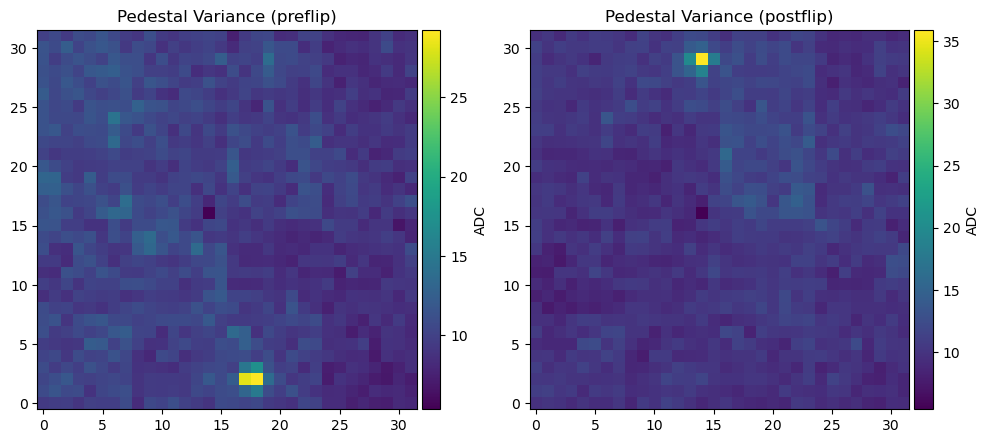

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

image1 = ax1.imshow(pedvar_preflip.reshape(32, 32), aspect="equal", origin='lower')
colorbar(image1, "ADC")
ax1.set_title("Pedestal Variance (preflip)")

image2 = ax2.imshow(pedvar_postflip.reshape(32, 32), aspect="equal", origin='lower')
colorbar(image2, "ADC")
ax2.set_title("Pedestal Variance (postflip)")

fig.tight_layout(h_pad=2)

A pixel sitting under a bright star will show an inflated pedestal variance in whichever field the star happens to fall in - that's the mismatch `gain_from_pedvars()` is designed to catch.

## Computing the Gain Map

In [8]:
from heap.make_gain_map import gain_from_pedvars

Call `gain_from_pedvars()` with `plotting=True` to see the full picture: the pedvar comparison, the ratio distribution used to flag star-affected pixels, and the resulting gain map.

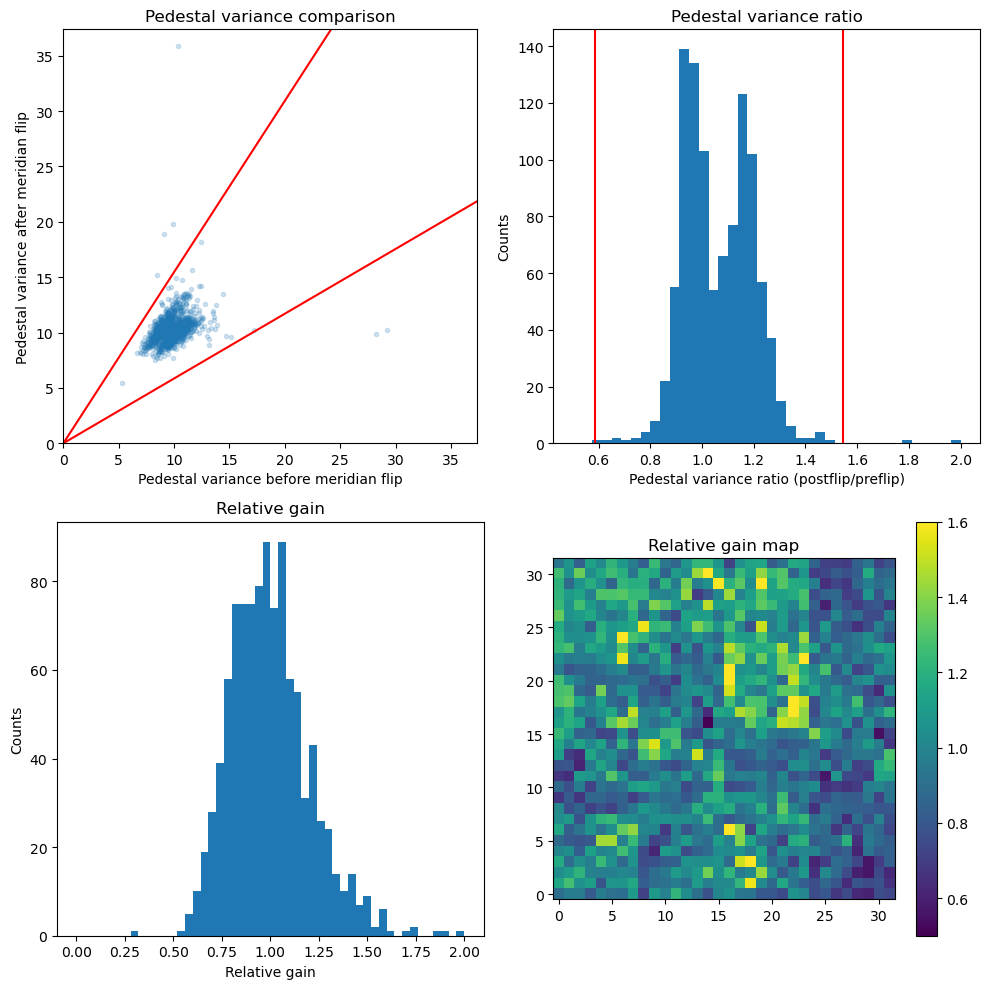

In [9]:
relgain = gain_from_pedvars(pedvar_preflip, pedvar_postflip, plotting=True)

`relgain` is the pixel-pixel relative gain map (in variance units, normalized to a mean of 1), reshaped to (32, 32).

Text(0.5, 1.0, 'Relative Gain Map')

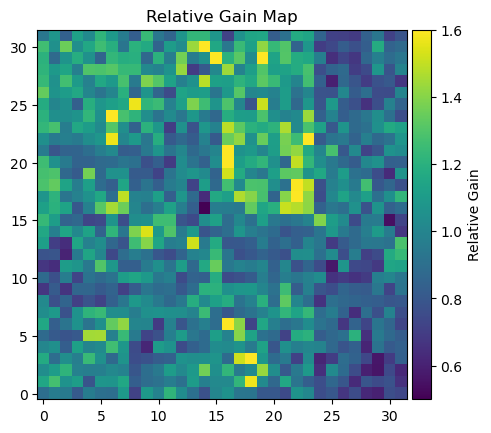

In [10]:
fig = plt.figure()
image = plt.imshow(relgain, aspect="equal", origin='lower', vmin=0.5, vmax=1.6)
colorbar(image, "Relative Gain")
plt.title("Relative Gain Map")

## Applying the Correction

In [11]:
event_num = 6755
raw_event = data_preflip[event_num].reshape(32, 32)
# gain correction alone, no pedestal subtraction
gain_only_event = raw_event / relgain
# pedestal subtraction alone
ped_sub_event = (data_preflip[event_num] - pedestal_preflip).reshape(32, 32)
# both, in the same order as threshold_clean
corrected_event = ped_sub_event / relgain                            

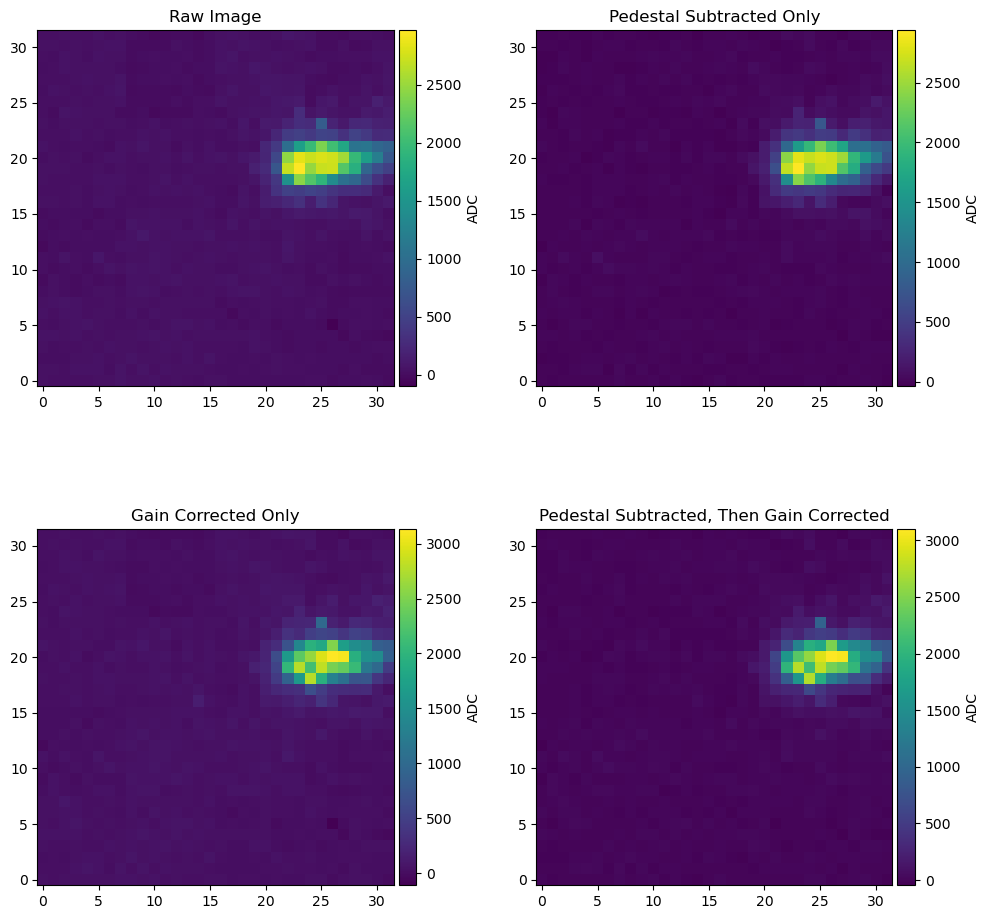

In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

image1 = ax1.imshow(raw_event, aspect="equal", origin='lower')
colorbar(image1, "ADC")
ax1.set_title("Raw Image")

image2 = ax2.imshow(ped_sub_event, aspect="equal", origin='lower')
colorbar(image2, "ADC")
ax2.set_title("Pedestal Subtracted Only")

image3 = ax3.imshow(gain_only_event, aspect="equal", origin='lower')
colorbar(image3, "ADC")
ax3.set_title("Gain Corrected Only")

image4 = ax4.imshow(corrected_event, aspect="equal", origin='lower')
colorbar(image4, "ADC")
ax4.set_title("Pedestal Subtracted, Then Gain Corrected")

fig.tight_layout(h_pad=2, w_pad=2)